# NLP 2026
# Lab 5: Prompting Large Language Models

LLMs are everywhere nowadays. You have probably used their many times and have seen their results. You might have seen good and bad results and that often how you ask the model to do something makes a big difference.
In this lab we will have a closer look at the prompting of LLMs. While often you would need to fine-tune the model for a specific task, you will see that prompting can be a powerful tool to shape the models responses.

An important distinction between this and the previous labs is that you will have to prepare a video presentation. You will find more information in the notebook.

By the end of this lab you should be able to:
- Load a pre-trained LLM
- Use the LLM to generate text
- Experiment with different prompting strategies
- Use the LLM to generate text based on the dataset
- Evaluate the generated text



### Exercises

In this lab the exercises are not graded. We will only grade the final video presentation. You can find the instructions in the last exercise ([Exercise 7](#e7)). The other exercises are there to guide you, and you should complete them as well, but they are not graded directly.

| Exercise          |
|-------------------|
| [Exercise 1](#e1) |
| [Exercise 2](#e2) |
| [Exercise 3](#e3) |
| [Exercise 4](#e4) |
| [Exercise 5](#e5) |
| [Exercise 6](#e6) |
| [Exercise 7](#e7) |

The maximum grade for this lab is 0.6 points.

### 📌 **Instructions for Delivery** (📅 **Deadline: 13/Mar 18:00**, 🎭 *wildcards possible*)

✅ **Submission Requirements**
+ 📄 You need to submit a **video presentation** that is no longer than 5 minutes and a **copy of your notebook** 📓 with the code.
+ ⚡ Make sure that **all cells are executed properly** ⚙️ and that **all figures/results/plots** 📊 you include in the presentation are also visible in your **executed notebook**.

✅ **Collaboration & Integrity**
+ 🗣️ While you may **discuss** the lab with others, you must **write your solutions with your group only**. If you **discuss specific tasks** with others, please **include their names** in the appendix of the report.
+ 📜 **Honor Code applies** to this lab. For more details, check **Syllabus §7.2** ⚖️.
+ 📢 **Mandatory Disclosure**:
   - Any **websites** 🌐 (e.g., **Stack Overflow** 💡) or **other resources** used must be **listed and disclosed**.
   - Any **GenAI tools** 🤖 (e.g., **ChatGPT**) used must be **explicitly mentioned**.
   - 🚨 **Failure to disclose these resources is a violation of academic integrity**. See **Syllabus §7.3** for details.

Collaborators: list collaborators here

**I talked with Jerry about...**

Use of genAI tools (e.g. chatGPT), websites (e.g. stackoverflow): list websites where you found code (or other info) as well as include information on how you used genAI tools (e.g. prompts):

I asked chatGPT about...

## 0. Setup
We start by making sure we have everything we need for this lab.


### 0.1 Using Google Colab

In this lab we will be generating text using LLMs. While we choose the small models for the exercises, they are still quite large and require a lot of memory. We recommend using google colab for this lab but you can also run it on your local machine if you have a GPU.

As mentioned before, Google Colab [https://colab.google/](https://colab.google/) gives you access to a GPU for a limited time (after you used this time you will have to wait for some time to use it again). To use a GPU you need to select the runtime type. Go to "Runtime -> Change runtime type". There you can select a CPU or a GPU.

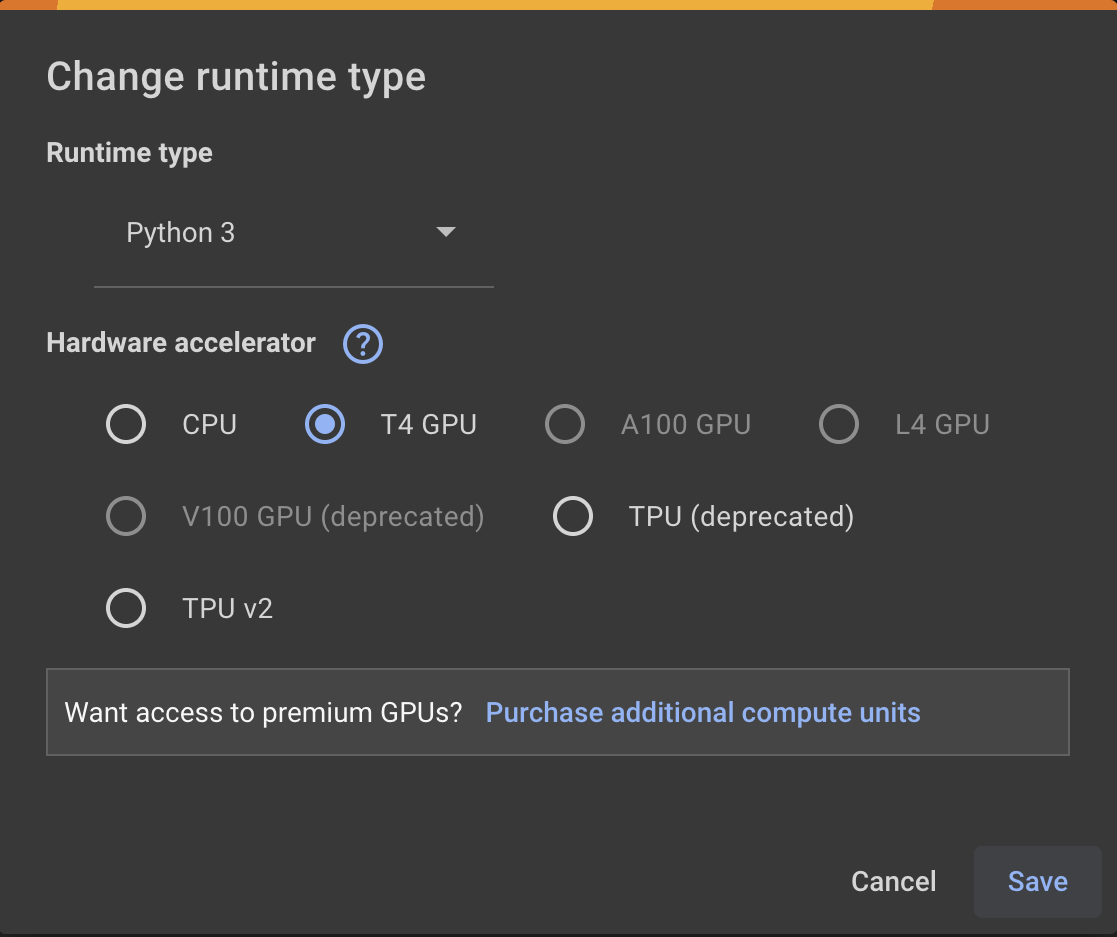

### 0.2 Installs and Imports

The following cell installs the required packages. You can run it if you are using Google Colab or if you are missing any of the packages. If you are using a local environment, you can copy the commands and run them in your terminal.

In [1]:
 ! pip install -U datasets
 ! pip install torch torchvision torchaudio
 ! pip install transformers
 ! pip install accelerate
 ! pip install sacrebleu

  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-3.6.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.18-py312-none-any.whl.metadata (7.5 kB)
  Using cached aiohttp-3.13.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.1 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (20 kB)
  Using cached multidict-6.7.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.3 kB)
  Using cached propcache-0.4.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527

In [2]:
! pip list | grep -E 'torch|transformers|datasets|accelerate'

accelerate                1.13.0
datasets                  4.7.0
torch                     2.10.0      2
torchaudio                2.10.0
torchvision               0.25.0
transformers              5.3.0


As usual, we start by importing some essential Python libraries that we will be using.

In [3]:
import math

import numpy as np
import matplotlib.pyplot as plt
import datasets
import transformers
import tqdm
import torch
import sacrebleu

/Users/george/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/george/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'sacrebleu'

## 1. Load and Preprocess Data

In this lab we will look at the task of summarization. The goal is to summarize a long text into a short form that encapsulates the meaning and the key information.

The dataset we are going to use can be found on [Huggingface](https://huggingface.co/datasets/EdinburghNLP/xsum). It contains documents and their summaries, aka it is a parallel corpus of documents and their equivalent summaries.

For example, for the document

`"The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail."`

the summary (based on the dataset) is:

`"Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud."`.


For more information you can read the original paper (from the University of Edinburgh) [here](https://aclanthology.org/D18-1206/).

### 1.1 Loading the Dataset

The dataset will be loaded as a huggingface dataset. We are going to limit the number of examples from each split, as the documents can be relatively long. You will thank me later, when you see how compute-hungry LLMs can be.

Make sure to inspect the dataset and make sure it is imported properly.

In [5]:
ds = datasets.load_dataset("EdinburghNLP/xsum", split=['train[0:200]', 'validation[0:200]', 'test[0:200]'])
ds = datasets.DatasetDict({
    'train': ds[0],
    'validation': ds[1],
    'test': ds[2],
})
print(ds)

DatasetDict({
    train: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 200
    })
    validation: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 200
    })
    test: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 200
    })
})


In [6]:
for i in range(10):
    print(ds['validation'][i])

{'document': 'The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.\nMr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.\nAppearing at the Old Bailey earlier, all four denied the offence.\nThe charge relates to offences which allegedly took place between 2008 and 2014.\nSam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.\nThey were all released on bail.', 'summary': 'Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.', 'id': '38295789'}
{'document': 'Voges was forced to retire hurt on 86 after suffering the injury while batting during the County Championship draw with Somerset on 4 June.\nMiddlesex hope to have the Australian back for their T20 Blast game against Hampshire at Lord\'s on 3 August.\nThe 37-year-old has scored 230 runs in

As in previous lab, we will be using the pre-trained tokenizer, so we can omit the cleaning process. You can still add it if you want more control over the data.

In [7]:
### YOUR CODE HERE



### YOUR CODE ENDS HERE

In this lab, we will be using only pre-trained models. That means that we won't be training any new model. This is the reason we can select only the `validation` and `test` subsets for evaluating the model. Do not delete the training subset as you will need it for the few-shot learning exercise.

### 1.2 Loading the Tokenizer

For the first part of this lab, we will be using a pre-trained LLM. We will be using the [Qwen2.5-0.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct) model from Alibaba Cloud. The model has been instruction-tuned (hence the "Instruct" in the name). It is very small with 0.5B parameters, but it should be enough for this lab. The paper is available [here](https://arxiv.org/abs/2407.10671).

We will specify the model name that can be found on the model's card on huggingface (revisit the first link). Make sure to check what other information Huggingface is offering (e.g. how to use the model, limitations, how to inference, etc.).

In [8]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

The models on huggingface come with their own tokenizers. They are loaded separately from the models. We can use [AutoTokenizer](https://huggingface.co/docs/transformers/v4.40.2/en/model_doc/auto#transformers.AutoTokenizer)'s `from_pretrained()` method to load it.

Inspect the output: The loaded object is of `Qwen2TokenizerFast` class.

In [9]:
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
print(tokenizer)

Qwen2Tokenizer(name_or_path='Qwen/Qwen2.5-0.5B-Instruct', vocab_size=151643, model_max_length=131072, padding_side='right', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151645: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151646: AddedToken("<|object_ref_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151647: AddedToken("<|object_ref_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151648: AddedToken("<|box_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151649: AddedToken("<|box_end|>", rstrip=Fa

Next, let's see how we can use it to tokenize some text.

In [10]:
print(ds['validation'][0]['summary'])
tokenized = tokenizer(ds['validation'][0]['summary'], padding=True, return_tensors='pt')
print("---")
print(type(tokenized))
print("---")
print(tokenized)

Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
---
<class 'transformers.tokenization_utils_base.BatchEncoding'>
---
{'input_ids': tensor([[30845, 19637,  8953,  8964,   261,  8224,   328,   347,  3756,   702,
          9723,   304,  5473, 16263,  2326, 20208, 13185,   315, 22846, 16124,
            13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


Examine the outputs: This is very similar to the output of the `tokenizer` function from the previous lab. This time we have two fields:
- `input_ids` - this is a PyTorch tensor with the indices of our tokens.
- `attention_mask` - holds the mask that the model will use to determine if the tokens in the `input_ids` are the real tokens or *padding*.

Let's detokenize the output of the tokenizer and inspect the outputs.

In [11]:
print(tokenized['input_ids'].shape)
print("---")
print(tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0]))
print("---")
print(len(tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0])))
print("---")
print(tokenizer.decode(tokenized['input_ids'][0], skip_special_tokens=False))
print("---")
print(tokenizer.decode(tokenized['input_ids'][0], skip_special_tokens=True))

torch.Size([1, 21])
---
['Former', 'ĠPremier', 'ĠLeague', 'Ġfootball', 'er', 'ĠSam', 'ĠS', 'od', 'je', 'Ġhas', 'Ġappeared', 'Ġin', 'Ġcourt', 'Ġalongside', 'Ġthree', 'Ġbrothers', 'Ġaccused', 'Ġof', 'Ġcharity', 'Ġfraud', '.']
---
21
---
Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
---
Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.


### 1.4 Loading the Model

In this section, we will load and examine the model. We will start with selecting the device we will place the model on. This will be a GPU (if one is available) or a CPU.

The following cell will select the device for us.

In [12]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cpu


Now, let's load the model from huggingface and place it on the device from the previous cell (the method `to()`).

In [13]:
model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
)
model.to(device)
print(model)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

What is the architecture of the model? You can take the outputs of the previous cell, check the model's card on huggingface, or read the paper linked above.

## 2. Prompting the Model

In this section we will explore some prompting techniques. Let us start with the very simple one: `"Summarize the following document: {DOCUMENT-TO-BE-SUMMARIZED} Summary: "`. The model should see the text and start generating the desired output (the summarized document). We will use an example from the dataset to test it. The `max_new_tokens` parameter specifies the maximum number of tokens to generate. The model will be forced to stop generating when it reaches this number of tokens.

In [14]:
document = ds['validation'][0]['document']
summary = ds['validation'][0]['summary']
prompt = f"Summarize the following document: {document} Summary: "
print('document:', document)
print('summary:', summary)
print('prompt:', prompt)

model_inputs = tokenizer([prompt], return_tensors="pt").to(model.device)
print(tokenized)
output_ids = model.generate(
    **model_inputs,
    max_new_tokens=512,
)

document: The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail.
summary: Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
prompt: Summarize the following document: The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offe

Let's examine the output. output.

In [15]:
print(tokenizer.decode(output_ids[0], skip_special_tokens=False))

Summarize the following document: The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail. Summary:  Reading defender denies fraud over £9m raised by Nigerian charity Sodje Sports Foundation. Mr Sodje, 37, is accused of fraud involving more than £9million raised by a charity for Nigerian sport. A jury found him guilty of two counts of fraud and sentenced him to six months in jail. He was also ordered to pay an additional £6,000 towards the costs of the prosecution's case. The judge said he had "no doubt" that the defendant w

You can see that our prompt is included in the output. The next cell should fix that.

In [16]:
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
]

We can re-examine the output. The `generated_ids` variable contains the generated tokens. We can decode them to get the generated text.

In [17]:
print(generated_ids)

generated_decoded = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print('full document:')
print(document)
print()
print('generated:')
print(generated_decoded)
print()
print('expected:')
print(summary)
print()


[tensor([17769, 28215, 46491, 16124,   916,  6938,    24,    76,  9226,   553,
        54333, 22846,   328,   347,  3756, 13180,  5007,    13,  4392,   328,
          347,  3756,    11,   220,    18,    22,    11,   374, 13185,   315,
        16124, 15860,   803,  1091,  6938,    24, 58313,  9226,   553,   264,
        22846,   369, 54333, 10552,    13,   362, 21234,  1730,  1435, 16007,
          315,  1378, 14579,   315, 16124,   323, 29131,  1435,   311,  4743,
         3951,   304, 17540,    13,  1260,   572,  1083, 11457,   311,  2291,
          458,  5107,  6938,    21,    11,    15,    15,    15,  6974,   279,
         7049,   315,   279, 31599,   594,  1142,    13,   576, 11651,  1053,
          566,  1030,   330,  2152, 10492,     1,   429,   279, 25799,  1035,
          537,   387,  2952,   311,  2291,   279,  2783,   315,   806,  1828,
         5777, 22835,   438,   264,  1102,   315,   279,  3311,  6398,   624,
          785,  5473,  6617,   429,  4392,   328,   347,  3756,

The response of the model is probably not great. This is because it has been trained as a chat-bot and it requires a certain structure of the conversation. Below the same prompt is passed to the chat template with a system prompt `You are Qwen, created by Alibaba Cloud. You are a helpful assistant.`. It is included in the `messages` list below. Let us see the result for the same prompt.

In [18]:
messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

print(text)

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Summarize the following document: The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail. Summary: <|im_end|>
<|im_start|>assistant



We can try this out using the next cell.

In [19]:
document = ds['validation'][0]['document']
summary = ds['validation'][0]['summary']
prompt = f"Summarize the following document: {document} Summary: "

messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

output_ids = model.generate(
    **model_inputs,
    max_new_tokens=512,
)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
]

generated_decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print('full document:')
print(document)
print()
print('generated:')
print(generated_decoded)
print()
print('expected:')
print(summary)
print()

full document:
The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail.

generated:
This summary provides an overview of the situation involving the ex-Reading defender who was accused of fraudulently trading funds for the Sodje Sports Foundation, a charity that raises money for Nigerian sports. Key points include:

1. **Charge Details**: Mr. Sodje, aged 37, is facing charges related to elder brothers Efe (44), Bright (50), and Stephen (42). All four defendants deny these charges.

2. **Timeframe**: The alleged offenses occu

<a name='e1'></a>
### Exercise 1: Examining and improving the prompt

Is the response as expected? Inspect more examples.

Try to improve the prompt and discuss the steps you have taken. Provide examples of the results. You should do at lest the following steps:
- Reformulate the text/wording of the prompt. Take into account the structure of the input text that is passed to the model.
- Add delimiters (such as "-----", new lines, etc.).
- Ask ChatGPT or other tool to generate a prompt for you.

In [24]:
# inspecting more examples with the original prompt
for i in range(3):
    document = ds['validation'][i]['document']
    summary = ds['validation'][i]['summary']
    prompt = f"Summarize the following document: {document} Summary: "

    messages = [
        {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
    output_ids = model.generate(**model_inputs, max_new_tokens=512)
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
    ]
    generated_decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    print(f'Example {i+1}')
    print('generated:', generated_decoded)
    print('expected:', summary)
    print()

# trying improved prompts
document = ds['validation'][0]['document']
summary = ds['validation'][0]['summary']

prompts = [
    # reformulated prompt
    f"Read the following document and write a concise summary of its main points. Document: {document}",
    
    # adding delimiters
    f"Summary: Summarize the following document:-----{document}-----",
    
    # prompt generated by chatgpt
    f"Summary: You are given a document below. Your task is to produce a brief and accurate summary that captures the key information and main points.-----Document:{document}-----Provide a concise summary of the above document:"
]

for prompt in prompts:
    messages = [
        {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
    output_ids = model.generate(**model_inputs, max_new_tokens=512)
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
    ]
    generated_decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    print('prompt:', prompt[:80], '...')
    print('generated:', generated_decoded)
    print('expected:', summary)
    print()

Example 1
generated: A 37-year-old man named Mr. Sodje was arrested after being accused of fraudulently trading sports funds for Nigerian athletes. He was jointly charged with his four brothers, Efe, Bright, and Stephen. The charges relate to activities that occurred between 2008 and 2014. All four men deny these allegations. They are expected to appear in court in July. The case involves sports funding scams involving young athletes in Nigeria.
expected: Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.

Example 2
generated: This summary provides information about Adam Voges' retirement from middlesex cricket due to an injury sustained while playing for his county team in the County Championship. It mentions that the 37-year-old batsman had previously played 4 first-class games and scored 230 runs in those matches at an average of 57.50. The document highlights that despite losing Voges, Middlesex hopes to have Adam bac

<a name='e2'></a>
### Exercise 2: Changing the system prompt
Now let us tinker a bit with the system prompt. Try to improve the generated summaries by changing the system prompt (`You are Qwen, created by Alibaba Cloud. You are a helpful assistant.`).
Did your results improve?

In [25]:
# trying different system prompts
document = ds['validation'][0]['document']
summary = ds['validation'][0]['summary']
prompt = f"Summarize the following document:-----{document}-----Summary:"

# system prompt 1
messages = [
    {"role": "system", "content": "You are a professional summarizer. Your task is to produce concise and accurate summaries of documents."},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
output_ids = model.generate(**model_inputs, max_new_tokens=512)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
]
generated_decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
print('System prompt 1: professional summarizer')
print('generated:', generated_decoded)
print('expected:', summary)
print()

# system prompt 2
messages = [
    {"role": "system", "content": "You are an expert at extracting key information from documents and writing brief, informative summaries."},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
output_ids = model.generate(**model_inputs, max_new_tokens=512)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
]
generated_decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
print('System prompt 2: expert at extracting key info') f
print('generated:', generated_decoded)
print('expected:', summary)
print()

# system prompt 3
messages = [
    {"role": "system", "content": "You are a helpful assistant specialized in summarization. Always respond with a short, factual summary."},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
output_ids = model.generate(**model_inputs, max_new_tokens=512)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
]
generated_decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
print('System prompt 3: specialized in summarization')
print('generated:', generated_decoded)
print('expected:', summary)

System prompt 1: professional summarizer
generated: A 37-year-old ex-reading defender has been charged with fraud by his four brothers over alleged trading activities related to the Sodje Sports Foundation, a charity that raises funds for Nigerian sports. The brothers deny the charges, though they were previously released on bail. They face trials in July.
expected: Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.

System prompt 2: expert at extracting key info
generated: The ex-reading student accused of fraud against the Sodje Sports Foundation has been found not guilty of charges related to the alleged fraudulent trading activities that occurred between 2008 and 2014. The case involves four individuals: Sam (from Kent), Efe (from Greater Manchester), Bright (from Greater Manchester) and Stephen (from Bexley). They have been released on bail pending their trial in July.
expected: Former Premier League footballer Sam S

<a name='e3'></a>
### Exercise 3: Few-shot learning

Hopefully, you got good results in the previous exercises, but you probably noticed that it is not that easy to make the model generate what you want. Explaining the model what "summary" means can be challenging.
Instead, we can use few-shot learning to show the model what we mean by "summarize". We can do this by providing a few examples of summarized documents in the form similar to the question-answer pairs. Here is one example:
```
Summarize the document at the end. Here are some examples of what is expected:
Document: {example_document}
Summary: {example_summary}
Document: {document}
Summary:
```

Where `example_document` and `example_summary` are the examples from dataset guiding the model to the desired answer.

Implement a few-shot learning prompt. Use the best prompt you achieved from the previous exercises. Make sure to use example(s) from the `train` dataset even for when testing on the `test` set. Experiment with different prompts and number of examples. Discuss the results.

In [44]:
### YOUR CODE HERE
example1_doc = ds['validation'][0]['document']
example1_sum = ds['validation'][0]['summary']

example2_doc = ds['validation'][1]['document']
example2_sum = ds['validation'][1]['summary']

document = ds['validation'][2]['document']

messages = [
    {"role": "system", "content": "You summarize news articles."},

    {"role": "user", "content": f"Document:\n{example1_doc}\n\nSummary:"},
    {"role": "assistant", "content": example1_sum},

    {"role": "user", "content": f"Document:\n{example2_doc}\n\nSummary:"},
    {"role": "assistant", "content": example2_sum},

    {"role": "user", "content": f"Document:\n{document}\n\nSummary:"}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

model_inputs = tokenizer([text], return_tensors="pt").to(device)

output_ids = model.generate(
    **model_inputs,
    max_new_tokens=128
)

generated_ids = [
    output_ids[len(input_ids):]
    for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
]

response = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print(response)

### YOUR CODE ENDS HERE

prompt:
Summarize the document at the end. Here are some examples of what is expected:
Document: The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.
Repair work is ongoing in Hawick and many roads in Peeblesshire remain badly affected by standing water.
Trains on the west coast mainline face disruption due to damage at the Lamington Viaduct.
Many businesses and householders were affected by flooding in Newton Stewart after the River Cree overflowed into the town.
First Minister Nicola Sturgeon visited the area to inspect the damage.
The waters breached a retaining wall, flooding many commercial properties on Victoria Street - the main shopping thoroughfare.
Jeanette Tate, who owns the Cinnamon Cafe which was badly affected, said she could not fault the multi-agency response once the flood hit.
However, she said more preventative work could have been carried out to ensure the retaining wall did not fail.
"It is difficult but I do think th

<a name='e4'></a>
### Exercise 4: Chain of Thought

One other influential prompting technique is Chain-of-Thought. It asks the model to approach the task at hand in an iterative manner. For our case of summarization it could mean first identifying the facts in the document, selecting the most important facts, and using them to form a summary. Here is an example:

```
Your task is to summarize the document at the end. First, identify the key facts, then select the most important ones and write a summary.
Document: {document}
Analysis:
```

Implement a chain-of-thought style prompt. Use the best prompt you achieved from the previous exercises as a basis. Try to improve the initial prompt you implemented. Discuss the results.

In [46]:
### YOUR CODE HERE
document = ds['validation'][0]['document']

prompt = f"""
Read the document and reason step by step.

Step 1: Identify the important facts.
Step 2: Identify the main message.
Step 3: Write a short summary.

Document:
{document}
"""

messages = [
    {"role": "system", "content": "You analyze documents carefully before summarizing."},
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

model_inputs = tokenizer([text], return_tensors="pt").to(device)

output_ids = model.generate(
    **model_inputs,
    max_new_tokens=200
)

generated_ids = [
    output_ids[len(input_ids):]
    for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
]

response = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print(response)




### YOUR CODE ENDS HERE

full document:
The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail.

generated:
The ex-Reading defender, Mr. Sodje, was charged with fraudulently trading funds related to the Sodje Sports Foundation, which raised money for Nigerian sports. He faces three counts of fraudulently trading, with the charges stemming from 2008 to 2014. He has been arrested in Kent, Greater Manchester, and Bexley, awaiting trial in July.

expected:
Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused

<a name='e5'></a>
### Exercise 5: Structured Chain of Thought

While just asking an LLM to analyze the inputs before answering can be helpful, we still run into the problem of explaining what a good analysis looks like. We can add structure to the model's reasoning by giving examples. Here is an example prompt:

```
Your task is to summarize the document at the end. First, identify the key facts, then select the most important ones and write a summary. Here are some examples of what is expected:
Document: {example_document}
Analysis:
- {example_fact_1}
- {example_fact_2}
- {example_fact_3}
Summary: {example_summary}
Document: {document}
Analysis:
```

Where `example_document` and `example_summary` are the same as before: examples from dataset guiding the model to the desired answer. For the facts (`example_fact_1`, ...) you can analyze the selected example and decide what are the facts to include in the prompt.

Implement a chain-of-thought prompt with example(s) of reasoning. Use the best prompt you achieved from the previous exercises as a starting point. As with few-shot learning, make sure to use example(s) from the `train` subset. Discuss the results.

In [48]:
### YOUR CODE HERE
document = ds['validation'][0]['document']

prompt = f"""
Analyze the following document.

Document:
{document}

Respond using this structure:

Facts:
- list key facts

Key Points:
- most important ideas

Summary:
- short final summary (2–3 sentences)
"""

messages = [
    {"role": "system", "content": "You analyze documents and produce structured summaries."},
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

model_inputs = tokenizer([text], return_tensors="pt").to(device)

output_ids = model.generate(
    **model_inputs,
    max_new_tokens=200
)

generated_ids = [
    output_ids[len(input_ids):]
    for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
]

response = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print(response)




### YOUR CODE ENDS HERE

The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.
Repair work is ongoing in Hawick and many roads in Peeblesshire remain badly affected by standing water.
Trains on the west coast mainline face disruption due to damage at the Lamington Viaduct.
Many businesses and householders were affected by flooding in Newton Stewart after the River Cree overflowed into the town.
First Minister Nicola Sturgeon visited the area to inspect the damage.
The waters breached a retaining wall, flooding many commercial properties on Victoria Street - the main shopping thoroughfare.
Jeanette Tate, who owns the Cinnamon Cafe which was badly affected, said she could not fault the multi-agency response once the flood hit.
However, she said more preventative work could have been carried out to ensure the retaining wall did not fail.
"It is difficult but I do think there is so much publicity for Dumfries and the Nith - and I totally appreciate that - but it is al

## 3. Applying it to the Dataset

In this section we will apply the model with a prompt to the whole `test` dataset. The prompt will be generated using `create_prompt` function. We will pass this function to the function generating the summaries (`generate_summary`). In the next section you can pass different prompt-generating functions to test their performances.

In [25]:
def create_prompt(document):
    prompt = f"""Summarize the following document: {document} Summary: """
    return prompt

The next function implements the tokenization of the prompts. It expects the list of prompts to tokenize them in a batch. Batching speeds up the generation process on the GPU. The function also takes the system prompt as an argument.

In [26]:
def tokenize_prompts(tokenizer, prompts, system_prompt):
    """
    Tokenizes the prompt for the model.
    Args:
        prompt: the prompt to use
        system_prompt: the system prompt to use

    Returns: the tokenized prompt

    """
    messages = [[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt}
    ] for prompt in prompts]
    texts = [tokenizer.apply_chat_template(
        message,
        tokenize=False,
        add_generation_prompt=True
    ) for message in messages]

    model_inputs = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, padding_side='left').to(model.device)
    return model_inputs

This function iterates over the dataset in batches, generates the prompt and applies tokenization. Finally, it asks the model to generate the compressed sentences. The function returns a list of generated sentences.

In [27]:
def generate_summary(dataset, model, tokenizer, create_prompt_fn, batch_size=8, system_prompt='You are Qwen, created by Alibaba Cloud. You are a helpful assistant.'):
    def collate_fn(batch):
        prompts = [create_prompt_fn(example['document']) for example in batch]
        model_inputs = tokenize_prompts(tokenizer, prompts, system_prompt)
        return model_inputs

    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, collate_fn=collate_fn)

    all_decoded = []
    model.eval()
    with torch.no_grad():
        for batch in tqdm.tqdm(dataloader, desc='Summarizing'):
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']

            output_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=512
            )

            generated_ids = [
                output_ids[len(input_id):]
                for input_id, output_ids in zip(input_ids, output_ids)
            ]

            generated_decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            all_decoded.extend(generated_decoded)

    return all_decoded


Here we will finally apply the model to the whole dataset. The `compressed_reference` variable will hold the reference compressed sentences and the `generated_compressed` variable will hold the generated compressed sentences.

Play around with the `batch_size` parameter to see how it affects the generation time. Incresing it should speed up the generation process, but it will also increase the memory usage.

In [33]:
reference_summaries = [example['summary'] for example in ds['validation']]
generated_summaries = generate_summary(ds['validation'], model, tokenizer, create_prompt, batch_size=16)

100%|██████████| 32/32 [03:26<00:00,  6.46s/it]


Let's examine a couple of generated examples before we move on to the evaluation.

In [29]:
for generated, reference in zip(generated_summaries[:10], reference_summaries[:10]):
    print(reference)
    print(generated)
    print('---')

GlobalFoundries challenging $160 million assessment
GlobalFoundries Inc. is actively contesting the $160 million assessment levied by the town of Malta on their property located at the Luther Forest Technology Campus in Malta.
---
Elderly couple found dead in home
The elderly couple, who were found dead in their home on Sunday afternoon, was identified as being from Lake City.
---
Alastair Cook dedicates 10th Test ton to Graham Gooch
ALASTAIR Cook's 10th Test ton was awarded to Graham Gooch by England, who emerged victorious over South Africa in their match.
---
Calhoun Community college to become first Alabama college to ban smoking
Calhoun Community College announces that it will be the first Alabama institution to implement strict smoke-free policies in September.
---
Can you be comfortable with being uncomfortable?
Two men on The Amazing Race stated that their success was achieved through being comfortable with discomfort.
---
Ri couple sentenced to prison for tax evasion
A Rhode I

## 4. Evaluating Prompting Strategies

In the previous section you manually examined the responses of the model. The problem with this approach is that you can only check a limited number of examples, and it is not that easy to compare the results. In this section, we will evaluate the model on the whole `test` dataset using two metrics:
- **average length** - this metric will measure how concise the model is. We will try to achieve similar average length as the reference sentences.
- **BLEU** - this metric will measure how similar the generated sentences are to the reference sentences. The BLEU score is a number between 0 and 100, and is calculated using overlap of n-grams between the hypothesis and the references. Refer ot the lecture slides and the [original paper](https://aclanthology.org/P02-1040/) for more information.

<a name='e6'></a>
### Exercise 6: Evaluating length

Implement the following function that calculates the average length (in words, split by space) of the sentences passed as a list of strings.

In [30]:
def calculate_average_length(sentences):
    """
    Calculate the length (in words) of the list of sentences.
    Args:
        sentences: a list of sentences
    Returns: the average length of the sentences
    """

    ### YOUR CODE HERE



    ### YOUR CODE ENDS HERE

We can calculate the average length of the references and the outputs of the model.

In [31]:
reference_mean_length = calculate_average_length(reference_summaries)
generated_max_length = calculate_average_length(generated_summaries)
print(f'Mean length of the references: {reference_mean_length}')
print(f'Mean length of the generated: {generated_max_length}')

Mean length of the references: 6.966
Mean length of the generated: 26.246


To calculate BLEU we will use the `sacrebleu` library ([https://github.com/MorinoseiMorizo/sacreBLEU](https://github.com/MorinoseiMorizo/sacreBLEU)). It expects the references to be passed as a list of lists. This was originally designed to support references from multiple translators (in the Machine Translation task), but in our case we will only use one reference for each example.

In [32]:
bleu_metric = sacrebleu.BLEU()

bleu = bleu_metric.corpus_score(hypotheses=generated_summaries, references=[reference_summaries])

print(bleu)
print(f"BLEU score: {bleu.score}")

BLEU = 4.61 15.6/7.0/2.9/1.4 (BP = 1.000 ratio = 4.015 hyp_len = 29106 ref_len = 7249)
BLEU score: 4.607686067374889


Now that you have all the components ready it's time to put it all into work.

## 5. Video Instructions

<a name='e7'></a>
### Exercise 7: Video presentation

Good news everyone! Your group is the new employees at the LearningRateAI company that wants to do LLM integration. The first task you got from your manager is to develop a tool (based on an LLM) to summarize the longer documents while preserving the main meaning. As newcomers naturally you want to impress everyone with your knowledge and expertize in Natural Language Processing.

You will summarize your work with a short video presentation (the graded part of the lab). Going over the notebook is not enough as the code would scare the managers. It should be no longer than 5 minutes. While you can be creative with the presentation, you should cover the following points:
- Compare prompting strategies you tried.
- Discuss the results of the few-shot learning. How many examples were needed to achieve the best results?
- For the chain-of-thought prompts, you will have to extract the summaries, as the output will contain the reasoning as well. What strategy did you implement? How effective it was?
- Try to find the best model for this task on the huggingface hub [https://huggingface.co/models?pipeline_tag=text-generation&sort=trending](https://huggingface.co/models?pipeline_tag=text-generation&sort=trending) (be mindful of the size of the model).
- What are other considerations the company should take into account when deploying the model?

Every team members has to present some part. You can use any video recording tool you like. Upload both the video and the notebook. Make sure that the notebook includes all the experiments and results you presented.
For the deliverable, **DO NOT go over the notebook** in the video, prepare slides instead.

In [ ]:
### YOUR CODE HERE




### YOUR CODE ENDS HERE